In [1]:
# ── Scene Configuration (only cell that differs per notebook) ─────────────────
SCENE_NAME = "duke"
SCENE_XML  = "../scene/scenes/Duke/scene.xml"

In [ ]:
import sys
import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

sys.path.append(os.path.abspath('../src'))

try:
    import sionna.rt
except ImportError:
    os.system("pip install sionna-rt")
    import sionna.rt

%matplotlib inline
import json
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import mitsuba as mi
import warnings

warnings.filterwarnings("ignore", message="invalid value encountered in multiply")
warnings.filterwarnings("ignore", category=UserWarning, module="jupyter_client")

from sionna.rt import load_scene, AntennaArray, PlanarArray
from sionna.rt.antenna_pattern import antenna_pattern_registry

from boresight_pathsolver import create_zone_mask
from multi_tx_optimizer import (
    optimize_multi_tx, setup_bs_transmitters, seed_jammer_positions, JammerConfig, compare_multi_tx_performance
)

scene = load_scene(SCENE_XML)
scene.frequency = 3.7e9

friendly_pattern = antenna_pattern_registry.get("iso")(polarization="V")
ue_pattern       = antenna_pattern_registry.get("iso")(polarization="V")

single_element = np.array([[0.0, 0.0, 0.0]])

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=1.0,
                             horizontal_spacing=1.0,
                             polarization="V",
                             pattern="tr38901")

jammer_array = AntennaArray(
    antenna_pattern=friendly_pattern,
    normalized_positions=single_element.T
)
scene.rx_array = AntennaArray(
    antenna_pattern=ue_pattern,
    normalized_positions=single_element.T
)

for radio_material in scene.radio_materials.values():
    radio_material.scattering_coefficient = 0.4

print(f"Scene loaded: {SCENE_NAME}  |  freq={scene.frequency/1e9} GHz")

/home/shr25/miniconda3/envs/optimize/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


2026-08-28 18:34:36 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Scene loaded: duke  |  freq=[3.7] GHz


In [3]:
def make_zone_params(shape: str, size_m: float) -> dict:
    """Return zone_params dict (always vertex-based) for the given shape and half-size.

    All shapes produce {"vertices": [...], "center": [0, 0]} so that every
    downstream function (seed_bs_positions, seed_jammer_positions,
    create_zone_mask) takes the same polygon code path.
    """
    if shape == "square":
        s = float(size_m)
        # Axis-aligned square: side = 2*size_m, centred at origin
        vertices = [(-s, -s), (s, -s), (s, s), (-s, s)]
        return {"center": [0.0, 0.0], "vertices": [(float(x), float(y)) for x, y in vertices]}

    if shape == "circle":
        r = float(size_m)
        # 64-point polygon approximation of a circle with radius = size_m
        theta = np.linspace(0, 2 * np.pi, 64, endpoint=False)
        vertices = [(round(r * np.cos(t), 3), round(r * np.sin(t), 3)) for t in theta]
        return {"center": [0.0, 0.0], "vertices": vertices}

    if shape == "splat":
        rng   = np.random.default_rng(seed=42)
        n_pts = 120
        theta = np.linspace(0, 2 * np.pi, n_pts, endpoint=False)
        r     = np.full(n_pts, size_m, dtype=float)
        for freq, (lo_f, hi_f) in [(2, (0.28, 0.44)), (3, (0.19, 0.33)),
                                    (4, (0.11, 0.21)), (5, (0.06, 0.12))]:
            amp   = rng.uniform(lo_f * size_m, hi_f * size_m)
            phase = rng.uniform(0, 2 * np.pi)
            r    += amp * np.cos(freq * theta + phase)
        r = np.clip(r, 0.35 * size_m, 1.65 * size_m)
        vertices = [
            (round(r[i] * np.cos(theta[i]), 2), round(r[i] * np.sin(theta[i]), 2))
            for i in range(n_pts)
        ]
        return {"center": [0.0, 0.0], "vertices": vertices}

    if shape == "l_shape":
        s = float(size_m)
        # 2S × 2S bounding box with top-right quadrant removed; sharp inner corner at origin
        vertices = [(-s, -s), (s, -s), (s, 0.0), (0.0, 0.0), (0.0, s), (-s, s)]
        return {"center": [0.0, 0.0], "vertices": [(float(x), float(y)) for x, y in vertices]}

    raise ValueError(f"Unknown shape: {shape!r}")


# Sanity check — all shapes should now produce a 'vertices' key
for _sh in ["square", "circle", "splat", "l_shape"]:
    _p = make_zone_params(_sh, 300)
    assert "vertices" in _p, f"{_sh} missing vertices!"
    print(f"{_sh:10s}: {len(_p['vertices'])} vertices, center={_p['center']}")

square    : 4 vertices, center=[0.0, 0.0]
circle    : 64 vertices, center=[0.0, 0.0]
splat     : 120 vertices, center=[0.0, 0.0]
l_shape   : 6 vertices, center=[0.0, 0.0]


In [ ]:
SHAPES = ["square"]

# Zone half-size chosen so a square zone has 100 m of side per BS:
#   small  → side 200 m (2 BS),  medium → side 300 m (3 BS),  large → side 400 m (4 BS)
SIZE_CONFIGS = [
    {"name": "large",  "size_m": 200.0, "n_bs": 3, "standoff_m": 75.0},
]

SAMPLE_COUNTS = [1000]

OUTPUT_ROOT = pathlib.Path(f"../results/{SCENE_NAME}")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MAP_CONFIG = {
    "center": [0.0, 0.0, 0.0],
    "size":   [1400, 1400],
    "cell_size": (0.5, 0.5),
    "ground_height": 0.0,
}

# Equation parameters — identical for every run
_base_hparams = dict(
    lds="Halton",
    sampler="rejection",
    sampling_strata="full",
    gamma_db=0.0,
    inside_margin_db=12.0,
    min_sinr_db=12.0,
    lambda_in=3.0,
    lambda_out=6.0,
    lambda_uniform=0.5,
    lambda_min_j=4.0,
    lambda_spread=0.0,
    spread_min_dist=0.0,
    soft_mean_weight=4.0,
    soft_mean_in_weight=4.0,
    learning_rate=0.1,
    lr_position=4.0,
    lr_power=0.1,
    noise_power=1e-10,
    lr_scheduler="cosine",
    # Learn per-element beamforming (precoding) weights for the 2x2 PlanarArray
    # jointly with angle/position/power, instead of the fixed uniform baseline.
    # lr_precoding left unset -> defaults to learning_rate.
    learn_precoding=True,
)

total_runs = len(SHAPES) * len(SIZE_CONFIGS) * len(SAMPLE_COUNTS)
print(f"Experiment: {SCENE_NAME}  |  {total_runs} total runs")
print(f"Output root: {OUTPUT_ROOT.resolve()}")

# Pre-compute Shapely building polygons once — passed to compare_multi_tx_performance
# so that building-interior cells are excluded from all SINR stats and CDFs.
from scene_parser import extract_building_info
from shapely.geometry import Polygon as _ShapelyPolygon
_building_info = extract_building_info(SCENE_XML, verbose=False)
BUILDING_POLYGONS = []
for _binfo in _building_info.values():
    try:
        verts_2d = [(float(c[0]), float(c[1])) for c in _binfo["vertices"]]
        _bp = _ShapelyPolygon(verts_2d)
        if _bp.is_valid:
            BUILDING_POLYGONS.append(_bp)
    except Exception:
        pass
print(f"Building polygons loaded: {len(BUILDING_POLYGONS)} (excluded from SINR stats)")

Experiment: duke  |  1 total runs
Output root: /home/shr25/service_aware_geometric_optimization/results/duke
Building polygons loaded: 152 (excluded from SINR stats)


In [5]:
def _remove_existing_bs(scene, max_n_bs=4):
    """Remove any BS transmitters left over from a previous iteration."""
    for idx in range(max_n_bs):
        try:
            scene.remove(f"bs_{idx}")
        except Exception:
            pass


def _seed_jammers_uniform(zone_params, shape, n_jammers=8,
                          standoff_distance=100.0, bs_positions=None):
    """Shape-aware jammer seeding.

    square  : n_jammers//4 jammers per side, spaced at equal intervals along
              each edge and pushed straight outward by standoff_distance — every
              jammer is at exactly standoff_distance from its nearest edge.
    circle  : equal arc-length interpolation on the round-buffered perimeter
              (equivalent to equal angular spacing).
    splat /
    l_shape : seed_jammer_positions() — concave-corner + convex-arc-peak feature
              seeding with angular gap fill, matching multi_tx_optimization.ipynb.
    """
    cx, cy = zone_params.get("center", [0.0, 0.0])

    if shape == "square":
        verts = zone_params["vertices"]
        s = max(abs(float(v[0]) - cx) for v in verts)  # half-side length
        n_per_side = max(1, n_jammers // 4)
        fracs = [(k + 0.5) / n_per_side for k in range(n_per_side)]
        sides = [
            ((cx - s, cy - s), (cx + s, cy - s), ( 0.0, -1.0)),  # south
            ((cx + s, cy - s), (cx + s, cy + s), ( 1.0,  0.0)),  # east
            ((cx + s, cy + s), (cx - s, cy + s), ( 0.0,  1.0)),  # north
            ((cx - s, cy + s), (cx - s, cy - s), (-1.0,  0.0)),  # west
        ]
        positions = []
        for (x0, y0), (x1, y1), (nx, ny) in sides:
            for f in fracs:
                bx = x0 + f * (x1 - x0)
                by = y0 + f * (y1 - y0)
                positions.append([bx + nx * standoff_distance,
                                   by + ny * standoff_distance])
        return positions

    if shape == "circle":
        from shapely.geometry import Polygon as ShapelyPolygon
        verts = [(float(v[0]) + cx, float(v[1]) + cy) for v in zone_params["vertices"]]
        poly  = ShapelyPolygon(verts)
        outer = poly.buffer(standoff_distance, join_style="round", resolution=64)
        ring  = outer.exterior
        total = ring.length
        return [
            [ring.interpolate((i + 0.5) / n_jammers * total).x,
             ring.interpolate((i + 0.5) / n_jammers * total).y]
            for i in range(n_jammers)
        ]

    # splat / l_shape: feature-based seeding (concave corners + convex arc peaks + gap fill)
    _bs = [[float(p[0]), float(p[1])] for p in bs_positions] if bs_positions else None
    return seed_jammer_positions(
        zone_params,
        n_jammers=n_jammers,
        bs_positions=_bs,
        standoff_distance=standoff_distance,
        min_bs_distance=75.0,
        concave_order=8,
        max_gap_deg=90.0,
        interpolation_factor=2,
        seed=22,
    )


def _extract_stats(stats_dict, tx_configs, use_jam=True):
    """Flatten per-TX stats into JSON-serialisable dicts with normalised key names.

    compare_multi_tx_performance stores SINR summaries under keys like
    'sinr_mean_db'; we remap to 'mean_db' for consistent access in analysis.
    When use_jam=True, prefer the jammer-present stats (containment_jam /
    sinr_inside_jam) and fall back to BS-only when not available.
    """
    out = {}
    for cfg in tx_configs:
        s = stats_dict[cfg.name]
        if use_jam:
            containment = s.get("containment_jam", s.get("containment", {})) or {}
            sinr_in  = s.get("sinr_inside_jam",  s.get("sinr_inside",  {})) or {}
            sinr_out = s.get("sinr_outside_jam", s.get("sinr_outside", {})) or {}
        else:
            containment = s.get("containment", {}) or {}
            sinr_in  = s.get("sinr_inside",  {}) or {}
            sinr_out = s.get("sinr_outside", {}) or {}
        out[cfg.name] = {
            "rho_leak": containment.get("rho_leak"),
            "rho_hole": containment.get("rho_hole"),
            "sinr_inside": {
                "mean_db":   sinr_in.get("sinr_mean_db"),
                "median_db": sinr_in.get("sinr_median_db"),
                "p10_db":    sinr_in.get("sinr_p10_db"),
                "p90_db":    sinr_in.get("sinr_p90_db"),
            },
            "sinr_outside": {
                "mean_db":   sinr_out.get("sinr_mean_db"),
                "median_db": sinr_out.get("sinr_median_db"),
                "p10_db":    sinr_out.get("sinr_p10_db"),
                "p90_db":    sinr_out.get("sinr_p90_db"),
            },
        }
    return out


N_JAMMERS = 8

run_index = 0
for shape in SHAPES:
    for size_cfg in SIZE_CONFIGS:
        for n_samples in SAMPLE_COUNTS:
            run_index += 1
            size_name  = size_cfg["name"]
            size_m     = size_cfg["size_m"]
            n_bs       = size_cfg["n_bs"]
            standoff_m = size_cfg["standoff_m"]
            run_tag   = f"{shape}_{size_name}_n{n_samples}"
            run_dir   = OUTPUT_ROOT / run_tag

            # ── Resume guard ──────────────────────────────────────────────────
            if (run_dir / "results.json").exists():
                print(f"[{run_index:>3}/{total_runs}] SKIP  {run_tag}")
                continue

            print(f"\n[{run_index:>3}/{total_runs}] START {run_tag}")
            run_dir.mkdir(parents=True, exist_ok=True)

            # ── Scene reset ───────────────────────────────────────────────────
            _remove_existing_bs(scene, max_n_bs=4)

            # ── Zone ──────────────────────────────────────────────────────────
            zone_params = make_zone_params(shape, size_m)
            zone_mask, _, zone_stats = create_zone_mask(
                map_config=MAP_CONFIG,
                zone_type="polygon" if "vertices" in zone_params else "box",
                zone_params=zone_params,
                target_height=1.5,
                scene_xml_path=SCENE_XML,
                exclude_buildings=True,
            )
            print(f"  Zone cells: {zone_stats['num_cells']}")

            # ── Base stations ─────────────────────────────────────────────────
            tx_configs, bs_positions_xyz = setup_bs_transmitters(
                scene=scene,
                zone_params=zone_params,
                n_bs=n_bs,
                scene_xml_path=SCENE_XML,
                bs_height=50.0,
                target_z=1.5,
                project_to_edge=True,
                name_prefix="bs",
                seed=44,
            )

            # ── Jammers: 8 evenly spaced on expanded zone perimeter ───────────
            jam_positions = _seed_jammers_uniform(
                zone_params, shape=shape, n_jammers=N_JAMMERS,
                standoff_distance=standoff_m,
                bs_positions=bs_positions_xyz,
            )
            jam_configs = [
                JammerConfig(name=f"jam_{k+1}", initial_power_dbm=20.0,
                             initial_position=pos)
                for k, pos in enumerate(jam_positions)
            ]
            print(f"  Jammers: {len(jam_configs)} evenly placed at "
                  f"{standoff_m:.0f} m standoff")

            # ── Shared kwargs ─────────────────────────────────────────────────
            # outside_half must cover jammer positions (~size_m + standoff) plus margin
            outside_half = size_m + standoff_m + 100.0
            _shared = dict(
                tx_configs=tx_configs,
                map_config=MAP_CONFIG,
                scene_xml_path=SCENE_XML,
                num_sample_points=n_samples,
                outside_half_size=outside_half,
                **_base_hparams,
            )

            # ── Run 1: BS-only warm-up (50 iter) ─────────────────────────────
            print("  Run 1: BS warm-up (50 iter)")
            result_bs, _ = optimize_multi_tx(
                scene=scene,
                jam_configs=None,
                num_iterations=15,
                **_shared,
            )
            elapsed_warmup = result_bs["joint"]["elapsed_time_s"]
            n_iter_warmup  = result_bs["joint"]["num_iterations"]
            print(f"  Warm-up: {elapsed_warmup:.1f}s total, "
                  f"{elapsed_warmup/n_iter_warmup:.2f}s/iter")

            # ── Warm-start Run 2 from Run 1 ───────────────────────────────────
            for cfg in tx_configs:
                r   = result_bs[cfg.name]
                pos = r["final_position"]
                scene.get(cfg.name).position = mi.Point3f(
                    float(pos[0]), float(pos[1]), float(pos[2])
                )
                cfg.initial_azimuth_deg, cfg.initial_elevation_deg = (
                    float(a) for a in r["best_angles"]
                )

            # ── Run 2: Joint BS + jammers (100 iter) ──────────────────────────
            print("  Run 2: Joint optimization (100 iter)")
            result_jam, jam_scene = optimize_multi_tx(
                scene=scene,
                jammer_array=jammer_array,
                jam_configs=jam_configs,
                num_iterations=20,
                **_shared,
            )
            elapsed_joint = result_jam["joint"]["elapsed_time_s"]
            n_iter_joint  = result_jam["joint"]["num_iterations"]
            print(f"  Joint:   {elapsed_joint:.1f}s total, "
                  f"{elapsed_joint/n_iter_joint:.2f}s/iter")

            # ── Evaluate: single call with jammers ────────────────────────────
            # compare_multi_tx_performance returns (fig_map, fig_cdf, stats).
            # When jam_scene is provided it computes both BS-only and BS+Jammer
            # SINR internally, so one call yields both conditions for CDF + map.
            print("  Evaluating...")
            zone_masks_dict = {cfg.name: zone_mask for cfg in tx_configs}
            fig_map, fig_cdf, stats_combined = compare_multi_tx_performance(
                scene=scene,
                tx_configs=tx_configs,
                multi_result=result_jam,
                map_config=MAP_CONFIG,
                zone_masks=zone_masks_dict,
                noise_power=1e-10,
                gamma_db=0.0,
                jam_scene=jam_scene,
                jammer_configs=jam_configs,
                building_polygons=BUILDING_POLYGONS,
            )
            fig_map.savefig(run_dir / "radiomap.png", dpi=150, bbox_inches="tight")
            fig_cdf.savefig(run_dir / "cdf_sinr.png",  dpi=150, bbox_inches="tight")
            plt.close("all")

            # ── Save results JSON ─────────────────────────────────────────────
            results = {
                "scene": SCENE_NAME,
                "shape": shape,
                "size_name": size_name,
                "size_m": size_m,
                "n_bs": n_bs,
                "n_samples": n_samples,
                "n_jammers": len(jam_configs),
                "timing": {
                    "warmup_elapsed_s":  elapsed_warmup,
                    "warmup_n_iter":     n_iter_warmup,
                    "warmup_avg_iter_s": elapsed_warmup / n_iter_warmup,
                    "joint_elapsed_s":   elapsed_joint,
                    "joint_n_iter":      n_iter_joint,
                    "joint_avg_iter_s":  elapsed_joint / n_iter_joint,
                    "total_elapsed_s":   elapsed_warmup + elapsed_joint,
                },
                "bs_only":      _extract_stats(stats_combined, tx_configs, use_jam=False),
                "with_jammers": _extract_stats(stats_combined, tx_configs, use_jam=True),
            }
            with open(run_dir / "results.json", "w") as f:
                json.dump(results, f, indent=2, default=float)

            print(f"  Saved → {run_dir}")

print(f"\nDone. {run_index} runs processed.")


[  1/1] START square_large_n1000
Creating polygon
  Zone cells: 449928
  bs_0: (121.3, -197.4, 50.0)
  bs_1: (-197.6, 144.0, 50.0)
  bs_2: (197.7, 171.8, 50.0)
  Jammers: 8 evenly placed at 75 m standoff
  Run 1: BS warm-up (50 iter)
-700.0

MULTI-TX SIR OPTIMIZATION  (3 transmitters)
Tx Position: [121.3282699584961, -197.4440155029297, 50.0]
look_at_position: [0.0, 0.0, 1.5]
Tx Position: [-197.57557678222656, 143.9962158203125, 50.0]
look_at_position: [0.0, 0.0, 1.5]
Tx Position: [197.7353057861328, 171.78868103027344, 50.0]
look_at_position: [0.0, 0.0, 1.5]
  [dbg] mean SINR_dB inside : 4.58192
  [dbg] mean SINR_dB outside: -9.95432
  [dbg] L_in=113.703  L_out=-21.4306  L_uniform=[0]  L_min_j=[0]  L_spread=[0]
  Iter   1/15  loss=660.7859  (3.8s)
  [dbg] mean SINR_dB inside : 4.8402
  [dbg] mean SINR_dB outside: -11.3534
  [dbg] L_in=116.29  L_out=-27.4882  L_uniform=[0]  L_min_j=[0]  L_spread=[0]
  Iter   2/15  loss=670.2537  (2.7s)
  [dbg] mean SINR_dB inside : 4.92548
  [dbg] mea

Loaded 1 result(s) from ../results/duke


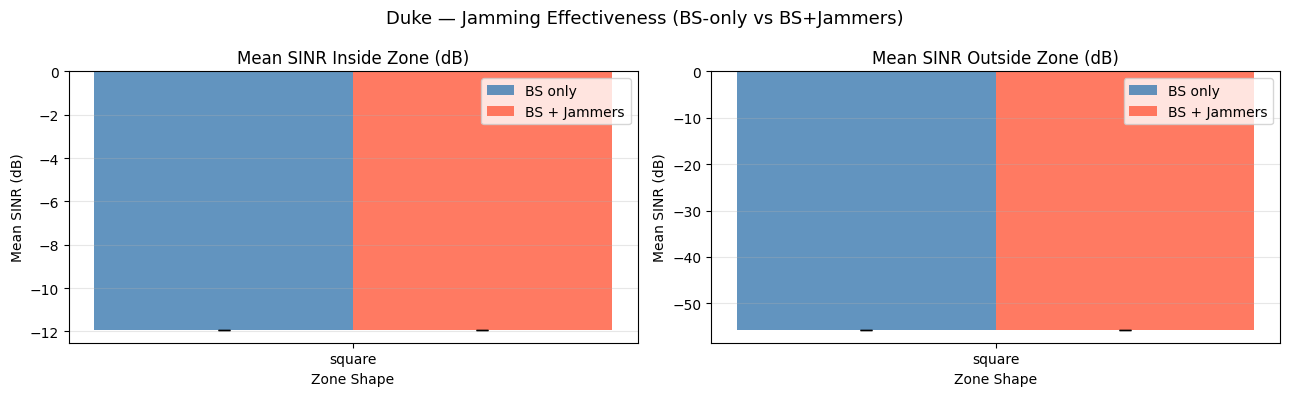

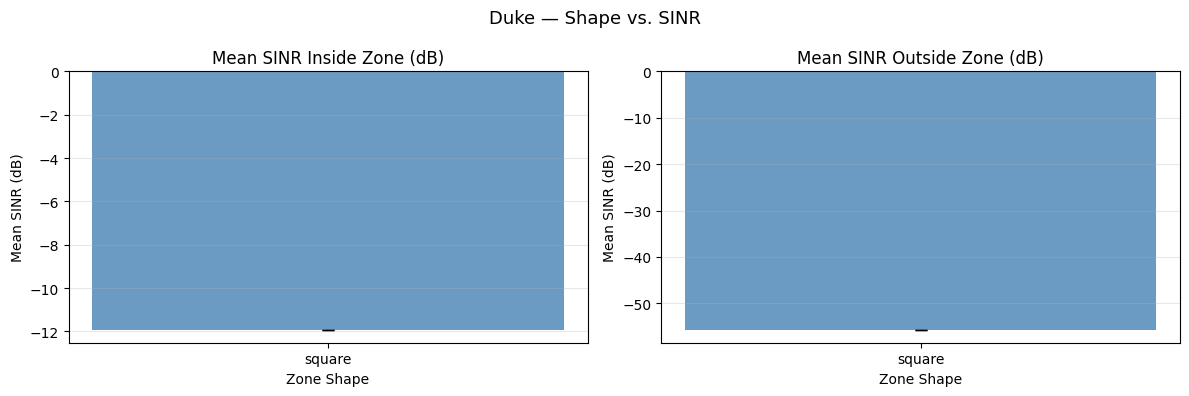

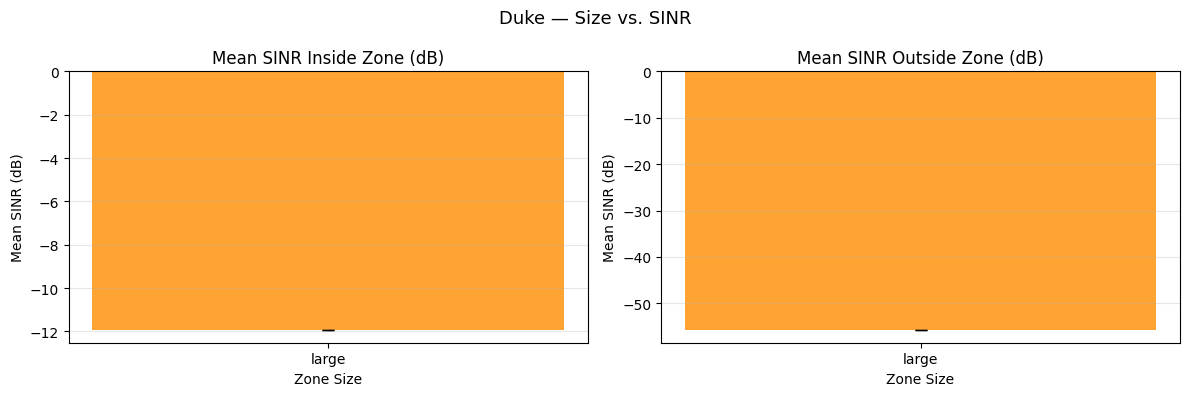

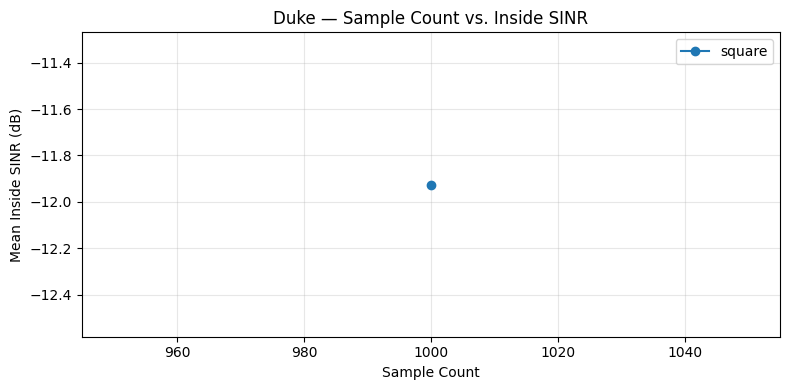

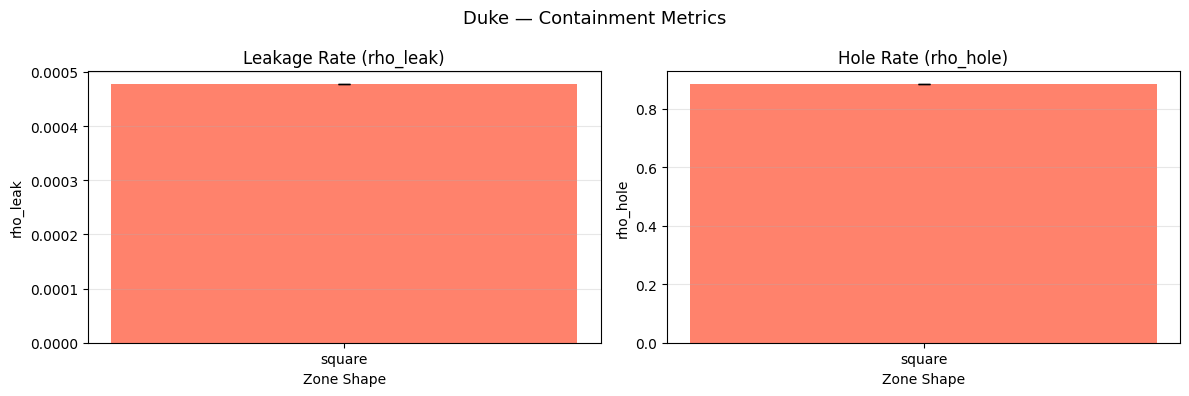

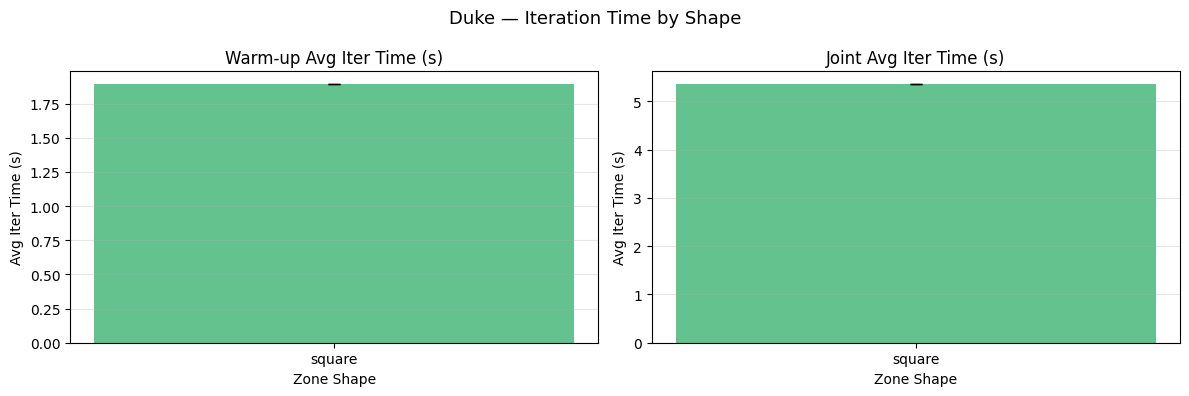

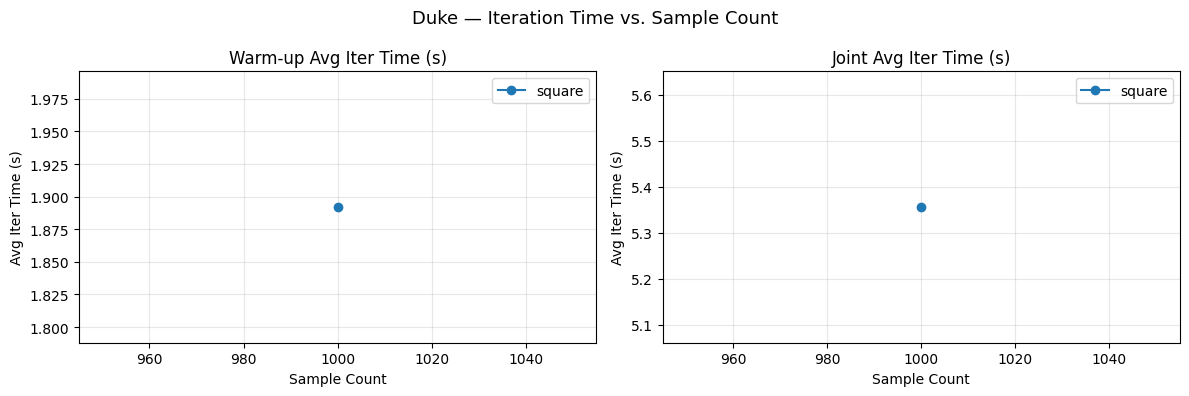


Run                                    In μ  In p10  In p90   Out μ    leak    hole  wu s/it  jt s/it   tot s
--------------------------------------------------------------------------------------------------------------
square_large_n1000                   -11.93  -25.20    0.66  -55.68  0.0005  0.8838     1.89     5.36   135.5

Analysis plots saved to: /home/shr25/service_aware_geometric_optimization/results/duke/analysis


In [6]:
# ── Collective Analysis ───────────────────────────────────────────────────────
# Loads all results.json files from OUTPUT_ROOT and generates comparison plots.

all_results = []
for json_path in sorted(OUTPUT_ROOT.rglob("results.json")):
    with open(json_path) as f:
        all_results.append(json.load(f))

print(f"Loaded {len(all_results)} result(s) from {OUTPUT_ROOT}")

if not all_results:
    raise RuntimeError("No results found. Run the experiment loop first.")

analysis_dir = OUTPUT_ROOT / "analysis"
analysis_dir.mkdir(exist_ok=True)


def _mean_sinr(r, key="with_jammers", region="sinr_inside", stat="mean_db"):
    return np.nanmean([v[region].get(stat, float("nan")) for v in r[key].values()])


def _mean_rho(r, key="with_jammers", metric="rho_leak"):
    vals = [v[metric] for v in r[key].values() if v[metric] is not None]
    return np.mean(vals) if vals else float("nan")


# ── 0. Jamming effectiveness: BS-only vs BS+Jammers ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
_x = np.arange(len(SHAPES))
_w = 0.35
for ax, region, title in [
    (axes[0], "sinr_inside",  "Mean SINR Inside Zone (dB)"),
    (axes[1], "sinr_outside", "Mean SINR Outside Zone (dB)"),
]:
    bs_means, bs_stds, jam_means, jam_stds = [], [], [], []
    for sh in SHAPES:
        bs_vals  = [_mean_sinr(r, key="bs_only",      region=region)
                    for r in all_results if r["shape"] == sh]
        jam_vals = [_mean_sinr(r, key="with_jammers", region=region)
                    for r in all_results if r["shape"] == sh]
        bs_means.append(np.nanmean(bs_vals));   bs_stds.append(np.nanstd(bs_vals))
        jam_means.append(np.nanmean(jam_vals)); jam_stds.append(np.nanstd(jam_vals))
    ax.bar(_x - _w / 2, bs_means,  _w, yerr=bs_stds,  capsize=4,
           label="BS only",      color="steelblue", alpha=0.85)
    ax.bar(_x + _w / 2, jam_means, _w, yerr=jam_stds, capsize=4,
           label="BS + Jammers", color="tomato",    alpha=0.85)
    ax.set_xticks(_x); ax.set_xticklabels(SHAPES)
    ax.set_xlabel("Zone Shape"); ax.set_ylabel("Mean SINR (dB)"); ax.set_title(title)
    ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.suptitle(f"{SCENE_NAME.title()} — Jamming Effectiveness (BS-only vs BS+Jammers)",
             fontsize=13)
plt.tight_layout()
fig.savefig(analysis_dir / "jamming_effectiveness.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 1. Shape vs. SINR ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, region, title in [
    (axes[0], "sinr_inside",  "Mean SINR Inside Zone (dB)"),
    (axes[1], "sinr_outside", "Mean SINR Outside Zone (dB)"),
]:
    by_shape = {sh: [] for sh in SHAPES}
    for r in all_results:
        by_shape[r["shape"]].append(_mean_sinr(r, region=region))
    means = [np.nanmean(by_shape[sh]) for sh in SHAPES]
    stds  = [np.nanstd(by_shape[sh])  for sh in SHAPES]
    ax.bar(SHAPES, means, yerr=stds, capsize=4, color="steelblue", alpha=0.8)
    ax.set_xlabel("Zone Shape"); ax.set_ylabel("Mean SINR (dB)"); ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle(f"{SCENE_NAME.title()} — Shape vs. SINR", fontsize=13)
plt.tight_layout()
fig.savefig(analysis_dir / "shape_vs_sinr.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Size vs. SINR ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
size_names = [c["name"] for c in SIZE_CONFIGS]
for ax, region, title in [
    (axes[0], "sinr_inside",  "Mean SINR Inside Zone (dB)"),
    (axes[1], "sinr_outside", "Mean SINR Outside Zone (dB)"),
]:
    by_size = {sn: [] for sn in size_names}
    for r in all_results:
        by_size[r["size_name"]].append(_mean_sinr(r, region=region))
    means = [np.nanmean(by_size[sn]) for sn in size_names]
    stds  = [np.nanstd(by_size[sn])  for sn in size_names]
    ax.bar(size_names, means, yerr=stds, capsize=4, color="darkorange", alpha=0.8)
    ax.set_xlabel("Zone Size"); ax.set_ylabel("Mean SINR (dB)"); ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle(f"{SCENE_NAME.title()} — Size vs. SINR", fontsize=13)
plt.tight_layout()
fig.savefig(analysis_dir / "size_vs_sinr.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Sample count vs. SINR inside ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for shape in SHAPES:
    by_n = {}
    for r in all_results:
        if r["shape"] == shape:
            by_n.setdefault(r["n_samples"], []).append(
                _mean_sinr(r, region="sinr_inside"))
    if by_n:
        ns = sorted(by_n)
        ax.plot(ns, [np.nanmean(by_n[n]) for n in ns], marker="o", label=shape)
ax.set_xlabel("Sample Count"); ax.set_ylabel("Mean Inside SINR (dB)")
ax.set_title(f"{SCENE_NAME.title()} — Sample Count vs. Inside SINR")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(analysis_dir / "samples_vs_sinr.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Containment metrics ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in [
    (axes[0], "rho_leak", "Leakage Rate (rho_leak)"),
    (axes[1], "rho_hole", "Hole Rate (rho_hole)"),
]:
    by_shape = {sh: [] for sh in SHAPES}
    for r in all_results:
        by_shape[r["shape"]].append(_mean_rho(r, metric=metric))
    means = [np.nanmean(by_shape[sh]) for sh in SHAPES]
    stds  = [np.nanstd(by_shape[sh])  for sh in SHAPES]
    ax.bar(SHAPES, means, yerr=stds, capsize=4, color="tomato", alpha=0.8)
    ax.set_xlabel("Zone Shape"); ax.set_ylabel(metric); ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle(f"{SCENE_NAME.title()} — Containment Metrics", fontsize=13)
plt.tight_layout()
fig.savefig(analysis_dir / "containment_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5. Timing: avg iteration time by shape ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, phase, key, title in [
    (axes[0], "warmup", "warmup_avg_iter_s", "Warm-up Avg Iter Time (s)"),
    (axes[1], "joint",  "joint_avg_iter_s",  "Joint Avg Iter Time (s)"),
]:
    by_shape = {sh: [] for sh in SHAPES}
    for r in all_results:
        v = r.get("timing", {}).get(key)
        if v is not None:
            by_shape[r["shape"]].append(v)
    means = [np.nanmean(by_shape[sh]) if by_shape[sh] else float("nan") for sh in SHAPES]
    stds  = [np.nanstd(by_shape[sh])  if by_shape[sh] else 0.0            for sh in SHAPES]
    ax.bar(SHAPES, means, yerr=stds, capsize=4, color="mediumseagreen", alpha=0.8)
    ax.set_xlabel("Zone Shape"); ax.set_ylabel("Avg Iter Time (s)"); ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle(f"{SCENE_NAME.title()} — Iteration Time by Shape", fontsize=13)
plt.tight_layout()
fig.savefig(analysis_dir / "timing_by_shape.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6. Timing: avg iteration time vs. sample count ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key, title in [
    (axes[0], "warmup_avg_iter_s", "Warm-up Avg Iter Time (s)"),
    (axes[1], "joint_avg_iter_s",  "Joint Avg Iter Time (s)"),
]:
    for shape in SHAPES:
        by_n = {}
        for r in all_results:
            if r["shape"] == shape:
                v = r.get("timing", {}).get(key)
                if v is not None:
                    by_n.setdefault(r["n_samples"], []).append(v)
        if by_n:
            ns = sorted(by_n)
            ax.plot(ns, [np.nanmean(by_n[n]) for n in ns], marker="o", label=shape)
    ax.set_xlabel("Sample Count"); ax.set_ylabel("Avg Iter Time (s)"); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle(f"{SCENE_NAME.title()} — Iteration Time vs. Sample Count", fontsize=13)
plt.tight_layout()
fig.savefig(analysis_dir / "timing_vs_samples.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 7. Summary table ─────────────────────────────────────────────────────────
print(f"\n{'Run':<35} {'In μ':>7} {'In p10':>7} {'In p90':>7} "
      f"{'Out μ':>7} {'leak':>7} {'hole':>7} {'wu s/it':>8} {'jt s/it':>8} {'tot s':>7}")
print("-" * 110)
for r in sorted(all_results, key=lambda x: (x["shape"], x["size_name"], x["n_samples"])):
    tag = f"{r['shape']}_{r['size_name']}_n{r['n_samples']}"
    t   = r.get("timing", {})
    print(
        f"{tag:<35} "
        f"{_mean_sinr(r, region='sinr_inside',  stat='mean_db'):>7.2f} "
        f"{_mean_sinr(r, region='sinr_inside',  stat='p10_db'):>7.2f} "
        f"{_mean_sinr(r, region='sinr_inside',  stat='p90_db'):>7.2f} "
        f"{_mean_sinr(r, region='sinr_outside', stat='mean_db'):>7.2f} "
        f"{_mean_rho(r, metric='rho_leak'):>7.4f} "
        f"{_mean_rho(r, metric='rho_hole'):>7.4f} "
        f"{t.get('warmup_avg_iter_s', float('nan')):>8.2f} "
        f"{t.get('joint_avg_iter_s',  float('nan')):>8.2f} "
        f"{t.get('total_elapsed_s',   float('nan')):>7.1f}"
    )

print(f"\nAnalysis plots saved to: {analysis_dir.resolve()}")